MNIST Numpy Neural Network From Scratch


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [18]:
#load data 
data  = pd.read_csv("/Users/aajinkyaingalkar/MNSIT Neural Network From Scratch/data/train.csv")
data.head()
data.tail()
data.shape

(42000, 785)

In [29]:
data = np.array(data)
m , n = data.shape
np.random.shuffle(data)
# Train Test Split
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n] / 255.
print(Y_train)

data_test = data[0:1000].T
Y_test = data_test[0]
X_test = data_test[1:n] / 255.

[1 4 7 ... 7 5 0]


In [30]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5

    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0, Z)

def Softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

#Forward Propagation

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = Softmax(Z2)

    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

#backward Propagation

def ReLU_deriv(Z):
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)

    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)

    return dW1, db1, dW2, db2
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2

    return W1, b1, W2, b2

In [36]:
"""What does np.argmax(A2, 0) mean?

argmax finds the index of the largest value.

The 0 means:

Look down each column."""

def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        if i % 100 == 0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1,b1,W2,b2

In [ ]:
W1,b1,W2,b2 = gradient_descent(X_train, Y_train, 0.1, 1000)

Iteration:  0
Accuracy:  0.11902439024390243
Iteration:  100
Accuracy:  0.6477560975609756
Iteration:  200
Accuracy:  0.7785609756097561
Iteration:  300
Accuracy:  0.8206097560975609
Iteration:  400
Accuracy:  0.8428048780487805
Iteration:  500
Accuracy:  0.8561951219512195
Iteration:  600
Accuracy:  0.8659268292682927
Iteration:  700
Accuracy:  0.8722439024390244
Iteration:  800
Accuracy:  0.877780487804878
Iteration:  900
Accuracy:  0.8823414634146342


In [47]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    if(prediction != label):
        print("Prediction is incorrect")
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [4]
Label:  0
Prediction is incorrect


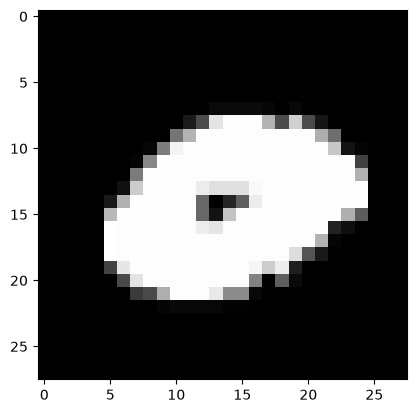

In [48]:
test_prediction(10001, W1, b1, W2, b2)